# 📊 EDA Inicial — Efectos Secundarios por Componente
## Dataset: Medicine Details (11.825 medicamentos)

**Objetivo:** Conocer el dataset antes de transformarlo.  
Responde: ¿Qué tenemos? ¿Qué calidad tienen los datos?

In [43]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.load_data import load_medicine_data
from validation import full_quality_report

# Cargar datos crudos
df_raw = load_medicine_data(download_if_missing=True)
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (11825, 9)


,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21


## 1. Vista general del dataset

In [21]:
print("=== TIPOS DE COLUMNAS ===")
print(df_raw.dtypes)

=== TIPOS DE COLUMNAS ===
Medicine Name           str
Composition             str
Uses                    str
Side_effects            str
Image URL               str
Manufacturer            str
Excellent Review %    int64
Average Review %      int64
Poor Review %         int64
dtype: object


In [23]:
df_raw[["Excellent Review %", "Average Review %", "Poor Review %"]].describe().round(2)

,Excellent Review %,Average Review %,Poor Review %
count,11825.00,11825.00,11825.00
mean,38.52,35.76,25.73
std,25.23,18.27,23.99
min,0.00,0.00,0.00
25%,22.00,27.00,0.00
50%,34.00,35.00,22.00
75%,51.00,47.00,35.00
max,100.00,88.00,100.00


## 2. Calidad de datos — Auditoría completa


In [33]:
report = full_quality_report(df_raw)

print(f"Shape: {report['shape']}")
print(f"Duplicados: {report['duplicates']}")
print(f"Reseñas inconsistentes (no suman ~100): {report['review_inconsistencies']}")
print(f"\nResumen de nulos:")

if report['null_summary'].empty:
    print("Sin valores nulos ")
else:
    display(report['null_summary'])

Shape: (11825, 9)
Duplicados: 84
Reseñas inconsistentes (no suman ~100): 0

Resumen de nulos:
Sin valores nulos 


### Interpretación
- Sin valores nulos en ninguna columna
- 84 duplicados detectados → se eliminarán en la etapa de limpieza
- Los porcentajes de reseñas suman correctamente ~100% en todos los registros

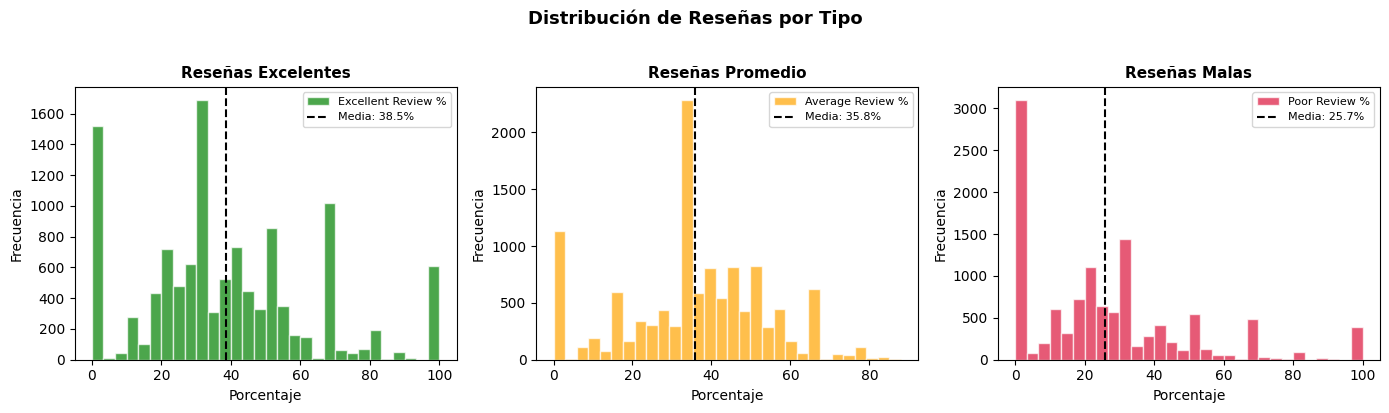

In [36]:
from pathlib import Path

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/tables").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
review_cols = ["Excellent Review %", "Average Review %", "Poor Review %"]
titulos = ["Reseñas Excelentes", "Reseñas Promedio", "Reseñas Malas"]
colors = ["green", "orange", "crimson"]

for ax, col, titulo, color in zip(axes, review_cols, titulos, colors):
    df_raw[col].plot(kind="hist", bins=30, ax=ax, color=color, alpha=0.7, edgecolor="white")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("Porcentaje")
    ax.set_ylabel("Frecuencia")
    ax.axvline(df_raw[col].mean(), color="black", linestyle="--",
               label=f"Media: {df_raw[col].mean():.1f}%")
    ax.legend(fontsize=8)

plt.suptitle("Distribución de Reseñas por Tipo", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/01_distribucion_resenas.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretación
- **Excellent Review %**: distribución amplia con media en 38.5%. Muchos medicamentos con 0% de excelentes.
- **Average Review %**: más centrada, media en 35.8%.
- **Poor Review %**: concentrada cerca de 0%, pero con cola larga. La mayoría tiene pocas reseñas negativas.

## 3. Vista previa del problema de limpieza

Antes de limpiar, identificamos el desafío estructural del dataset:

- `Composición`: componentes separados por `+` con dosificaciones entre paréntesis.  
  Ejemplo: `Amoxycillin (500mg) + Clavulanic Acid (125mg)`

- `Efectos secundarios`: efectos concatenados **sin comas**, usando mayúscula inicial como separador implícito.  
  Ejemplo: `Vomiting Nausea Diarrhea` → tres efectos distintos en un solo string.

Este problema en los efectos secundarios es la **decisión técnica más importante** del proyecto y se aborda en detalle en el notebook de limpieza.

In [37]:
ejemplos = df_raw[["Medicine Name", "Composition", "Side_effects"]].head(4)
for _, row in ejemplos.iterrows():
    print(f"   Medicamento        : {row['Medicine Name']}")
    print(f"   Composición        : {row['Composition']}")
    print(f"   Efectos secundarios: {row['Side_effects']}")
    print()

   Medicamento        : Avastin 400mg Injection
   Composición        : Bevacizumab (400mg)
   Efectos secundarios: Rectal bleeding Taste change Headache Nosebleeds Back pain Dry skin High blood pressure Protein in urine Inflammation of the nose

   Medicamento        : Augmentin 625 Duo Tablet
   Composición        : Amoxycillin  (500mg) +  Clavulanic Acid (125mg)
   Efectos secundarios: Vomiting Nausea Diarrhea Mucocutaneous candidiasis

   Medicamento        : Azithral 500 Tablet
   Composición        : Azithromycin (500mg)
   Efectos secundarios: Nausea Abdominal pain Diarrhea

   Medicamento        : Ascoril LS Syrup
   Composición        : Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml) + Guaifenesin (50mg/5ml)
   Efectos secundarios: Nausea Vomiting Diarrhea Upset stomach Stomach pain Allergic reaction Dizziness Headache Rash Hives Tremors Palpitations Muscle cramp Increased heart rate



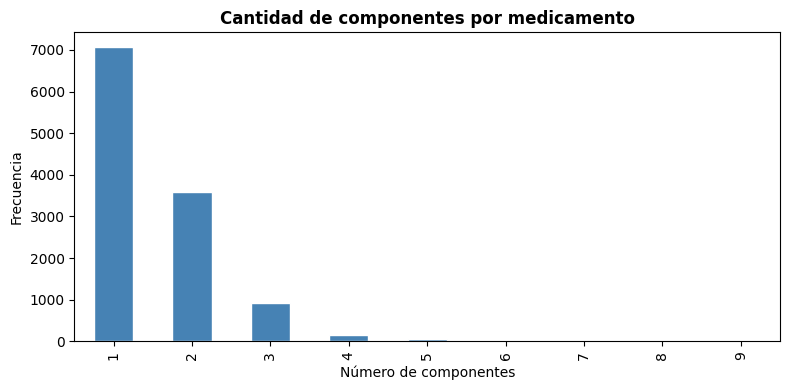

count    11825.00
mean         1.53
std          0.77
min          1.00
25%          1.00
50%          1.00
75%          2.00
max          9.00
Name: Composition, dtype: float64


In [38]:
n_componentes_aprox = df_raw["Composition"].str.count(r"\+") + 1

fig, ax = plt.subplots(figsize=(8, 4))
n_componentes_aprox.value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("Cantidad de componentes por medicamento", fontweight="bold")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("../outputs/figures/01_componentes_por_medicamento.png", dpi=150, bbox_inches="tight")
plt.show()

print(n_componentes_aprox.describe().round(2))

In [39]:
ejemplos = df_raw[["Medicine Name", "Composition", "Side_effects"]].head(4)
for _, row in ejemplos.iterrows():
    print(f"   Medicamento        : {row['Medicine Name']}")
    print(f"   Composición        : {row['Composition']}")
    print(f"   Efectos secundarios: {row['Side_effects']}")
    print()

   Medicamento        : Avastin 400mg Injection
   Composición        : Bevacizumab (400mg)
   Efectos secundarios: Rectal bleeding Taste change Headache Nosebleeds Back pain Dry skin High blood pressure Protein in urine Inflammation of the nose

   Medicamento        : Augmentin 625 Duo Tablet
   Composición        : Amoxycillin  (500mg) +  Clavulanic Acid (125mg)
   Efectos secundarios: Vomiting Nausea Diarrhea Mucocutaneous candidiasis

   Medicamento        : Azithral 500 Tablet
   Composición        : Azithromycin (500mg)
   Efectos secundarios: Nausea Abdominal pain Diarrhea

   Medicamento        : Ascoril LS Syrup
   Composición        : Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml) + Guaifenesin (50mg/5ml)
   Efectos secundarios: Nausea Vomiting Diarrhea Upset stomach Stomach pain Allergic reaction Dizziness Headache Rash Hives Tremors Palpitations Muscle cramp Increased heart rate



### Interpretación
Se puede observar claramente el problema estructural del dataset:

- Los **efectos secundarios** están concatenados sin separador explícito. Por ejemplo: `Rectal bleeding Taste change Headache` son 3 efectos distintos escritos como un solo string.
- La **composición** usa `+` como separador y dosificaciones entre paréntesis que deben eliminarse.

Esto confirma que la limpieza con expresiones regulares es **indispensable** antes de cualquier análisis.

## 4. Conclusiones del EDA Inicial

- El dataset tiene **11.825 registros** y **9 columnas**, sin valores nulos.
- Se detectaron **84 duplicados** que serán eliminados en la etapa de limpieza.
- Las reseñas están correctamente distribuidas y suman ~100% en todos los registros.
- La mayoría de los medicamentos tiene **1 o 2 componentes activos**.
- El principal desafío técnico es la columna de efectos secundarios: requiere separación por mayúscula inicial usando expresiones regulares.

➡️ El siguiente notebook aborda la limpieza y transformación completa del dataset.